# Distribution Analysis

> Understanding the structure of the Diabetes 130-US dataset before running federated experiments.
> This notebook has two goals:
> 1. **Global distributions** — class-conditional feature statistics that inform what the FedGen generator *should* learn to approximate.
> 2. **Dirichlet heterogeneity** — how client distributions diverge from the global as α decreases, providing an empirical basis for the accuracy-vs-communication-cost Pareto analysis.

---

# First chapter: Clinical Analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import wasserstein_distance, entropy, ks_2samp
import warnings
import sys
import os
import json

warnings.filterwarnings('ignore')
sys.path.append('..')

from UC1Utils import (
    load_data, drop_columns, remove_deceased, create_target,
    encode_features, _impute_and_group_specialty,
    prepare_data, ensure_data, CSV_MAIN, derive_global_columns
)
from UC1FLUtils import dirichlet_partition, find_feasible_params, preprocess_clients, verify_leakage, load_clients, create_clients_raw_csv, load_partitions_from_disk

from UC1PrintingUtils import (
    plot_class_distribution,
    plot_continuous_features,
    plot_categorical_features,
    plot_engineered_features,
    plot_feature_correlations,
)


plt.rcParams.update({
    'figure.dpi':       130,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size':        11,
})
PALETTE = {'Not readmitted (0)': '#4878CF', 'Readmitted <30d (1)': '#E24A33'}
CONTINUOUS_FEATURES = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses',
    'service_utilization', 'medication_count', 'age'
]
ALPHA_SWEEP = [0.1, 0.5, 1.0, 5.0,10.0]
N_CLIENTS   = 5
SEED        = 42
FEDERATED_DIR  = '../federated_data'
FILTERED_DIR   = os.path.join(FEDERATED_DIR, 'filtered')
UNFILTERED_DIR = os.path.join(FEDERATED_DIR, 'unfiltered')

os.makedirs('figures', exist_ok=True)
print('Setup complete.')

Setup complete.


## 1. Load Data

We work at two levels:
- **Raw DataFrame** (pre-OHE) — for clinical feature distributions.
- **Encoded matrix** (post-OHE) — for federated partitioning and Wasserstein analysis.

In [19]:
ensure_data()

# ── Load and preprocess up to (but not including) OHE ─────────────────────────
# We keep a pre-OHE DataFrame for clinical interpretation.
df_raw = load_data(CSV_MAIN)
df_raw = drop_columns(df_raw)
df_raw = remove_deceased(df_raw)
df_raw = create_target(df_raw)
df_raw['race'] = df_raw['race'].fillna('Unknown')
df_raw = _impute_and_group_specialty(df_raw)
df_raw['A1Cresult']     = df_raw['A1Cresult'].fillna('none')
df_raw['max_glu_serum'] = df_raw['max_glu_serum'].fillna('none')
df_raw.dropna(inplace=True)

# Apply encode_features which adds engineered columns but also OHEs —
# we'll rebuild a pre-OHE version for visualization.
# The approach: apply everything EXCEPT get_dummies by reconstructing manually.
from UC1Utils import AGE_MAP, ADMISSION_TYPE_MAP, ADMISSION_SOURCE_MAP, MED_MAP, MED_COLS, LOW_INFO_MEDS
from UC1Utils import group_discharge, group_icd9

df = df_raw.copy()
df['age'] = df['age'].map(AGE_MAP)
df['service_utilization'] = df['number_inpatient'] + df['number_outpatient'] + df['number_emergency']
df['admission_type_id']        = df['admission_type_id'].map(ADMISSION_TYPE_MAP).fillna('unknown')
df['admission_source_id']      = df['admission_source_id'].map(ADMISSION_SOURCE_MAP).fillna('unknown')
df['discharge_disposition_id'] = df['discharge_disposition_id'].apply(group_discharge)
for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col] = df[col].apply(group_icd9)
for col in MED_COLS:
    if col in df.columns:
        df[col] = df[col].map(MED_MAP)
active_meds = [c for c in MED_COLS if c in df.columns]
df['medication_count'] = df[active_meds].sum(axis=1)
df.drop(columns=[c for c in LOW_INFO_MEDS if c in df.columns], inplace=True)
df['HbA1c_diabetes_interaction'] = (
    (df['A1Cresult'] != 'none') & (df['diag_1'] == 'diabetes')
).astype(int)
df['change']      = (df['change'] == 'Ch').astype(int)
df['diabetesMed'] = (df['diabetesMed'] == 'Yes').astype(int)

# ── Fully encoded matrix ───────────────────────────────────────────────────────
X, y, groups, feature_names = prepare_data(CSV_MAIN, verbose=True)

df_enc = pd.DataFrame(X, columns=feature_names)
df_enc['readmitted_binary'] = y

print(f'\nPre-OHE DataFrame: {df.shape}')
print(f'Encoded matrix:    {df_enc.shape}')

✓ CSV files already present, skipping extraction.
dropna removed 1518 rows (1.53%) — likely from unmapped admission_type/source IDs
Dataset shape after cleaning: (97825, 101)
Class distribution:
readmitted_binary
0    86618
1    11207
Name: count, dtype: int64
Imbalance ratio: 7.73:1  (positive rate: 11.46%)

Pre-OHE DataFrame: (97825, 40)
Encoded matrix:    (97825, 100)


## 2. Global Class Distribution

The 7.73:1 imbalance is the single most structurally important property of this dataset.
It directly affects what the generator must learn: class 1 is rare, so its latent
representations are also sparsely sampled during generator training.

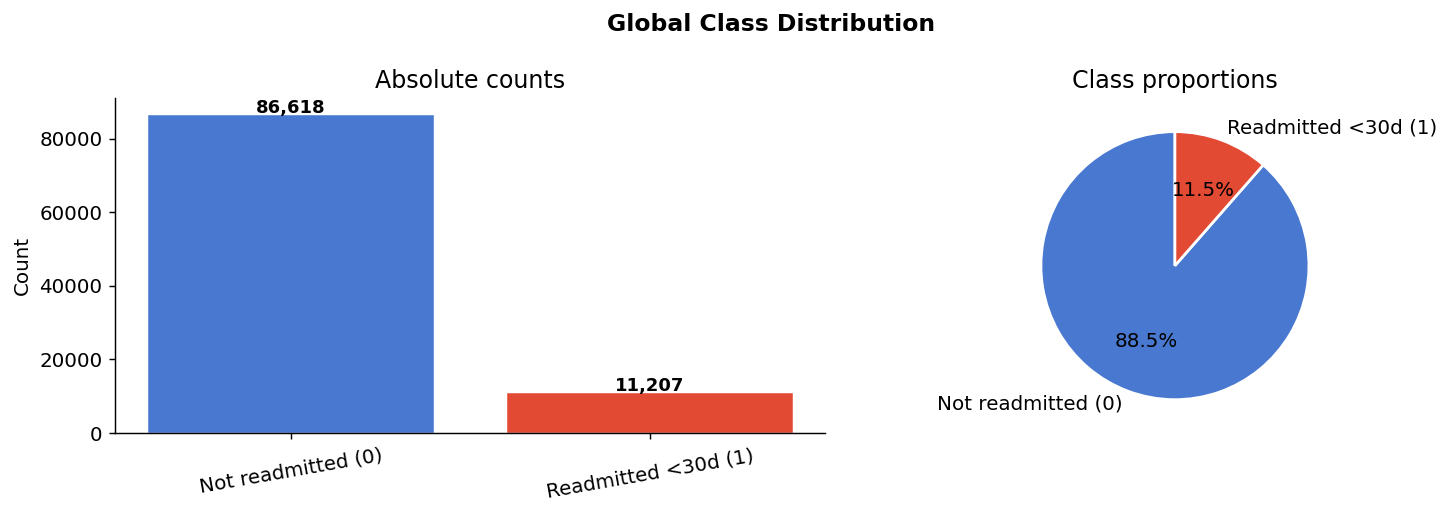

Imbalance ratio: 7.73:1  |  Positive rate: 11.46%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Global Class Distribution', fontweight='bold', fontsize=13)

counts = pd.Series(y).value_counts().sort_index()
labels = ['Not readmitted (0)', 'Readmitted <30d (1)']
colors = list(PALETTE.values())

axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=0.8)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 300, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_title('Absolute counts')
axes[0].tick_params(axis='x', rotation=10)

axes[1].pie(
    counts.values, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Class proportions')

plt.tight_layout()
plt.savefig('figures/01_class_distribution.png', bbox_inches='tight')
plt.show()

print(f'Imbalance ratio: {counts[0]/counts[1]:.2f}:1  |  Positive rate: {counts[1]/len(y)*100:.2f}%')

# Cell 6
plot_class_distribution(y, PALETTE)

# Cell 8
plot_continuous_features(df, y, CONTINUOUS_FEATURES, PALETTE)

# Cell 10
plot_categorical_features(df, y, CAT_FEATURES, PALETTE)

# Cell 12
plot_engineered_features(df, y, PALETTE)

# Cell 14
plot_feature_correlations(df, CONTINUOUS_FEATURES)

## 3. Class-Conditional Distributions: Continuous Features

These are the features whose class-conditional distributions the generator is implicitly
trying to capture in latent space. Large separations between the two class distributions
indicate high discriminative power — and also indicate where a biased local dataset
will produce the worst model drift.

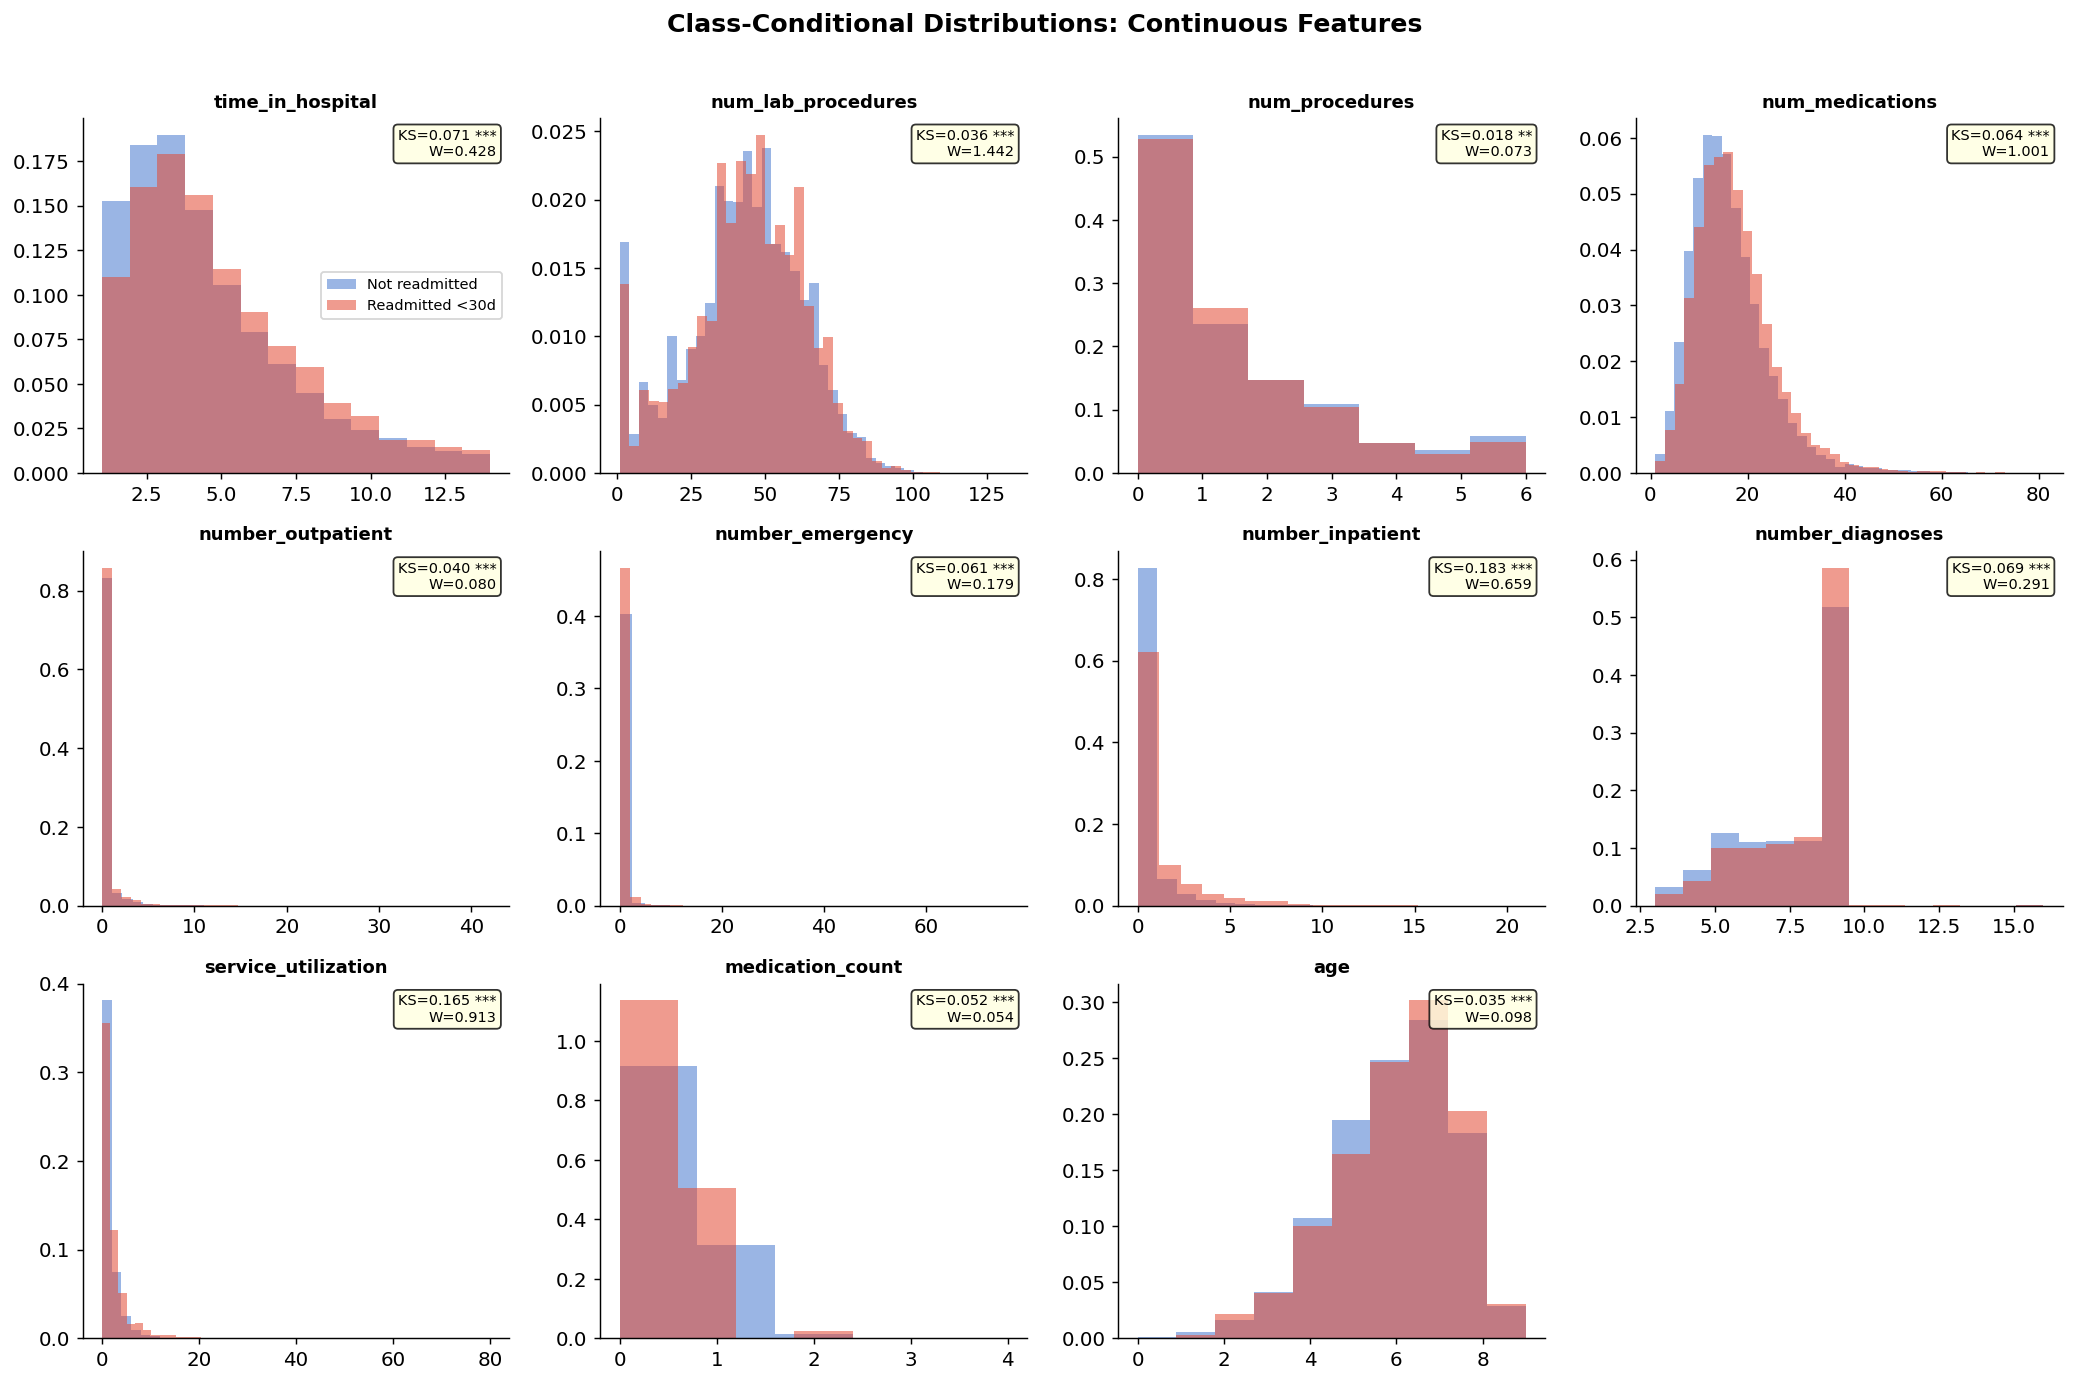


Kolmogorov-Smirnov test: class-conditional separation
(Higher KS = more discriminative, more sensitive to distribution shift)

            Feature  KS statistic       p-value Significant
   number_inpatient      0.183136 9.717136e-292         ***
service_utilization      0.164981 1.659051e-236         ***
   time_in_hospital      0.071369  2.139068e-44         ***
   number_diagnoses      0.068886  2.184919e-41         ***
    num_medications      0.064051  7.788025e-36         ***
   number_emergency      0.061086  1.245366e-32         ***
   medication_count      0.052175  6.441043e-24         ***
  number_outpatient      0.040167  2.393455e-14         ***
 num_lab_procedures      0.035678  2.073279e-11         ***
                age      0.034581  9.583534e-11         ***
     num_procedures      0.017578  4.290620e-03            


In [ ]:


n_cols = 4
n_rows = int(np.ceil(len(CONTINUOUS_FEATURES) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
fig.suptitle('Class-Conditional Distributions: Continuous Features', fontweight='bold', fontsize=14, y=1.01)
axes = axes.flatten()

df0 = df[df['readmitted_binary'] == 0]
df1 = df[df['readmitted_binary'] == 1]

ks_results = {}

for i, feat in enumerate(CONTINUOUS_FEATURES):
    ax = axes[i]
    v0 = df0[feat].dropna()
    v1 = df1[feat].dropna()

    ks_stat, ks_p = ks_2samp(v0, v1)
    ks_results[feat] = (ks_stat, ks_p)
    wass = wasserstein_distance(v0, v1)

    # KDE plots
    bins = min(40, int(v0.nunique()))
    ax.hist(v0, bins=bins, alpha=0.55, color=list(PALETTE.values())[0],
            density=True, label='Not readmitted')
    ax.hist(v1, bins=bins, alpha=0.55, color=list(PALETTE.values())[1],
            density=True, label='Readmitted <30d')

    ax.set_title(f'{feat}', fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    sign = '***' if ks_p < 0.001 else ('**' if ks_p < 0.01 else ('*' if ks_p < 0.05 else 'ns'))
    ax.annotate(f'KS={ks_stat:.3f} {sign}\nW={wass:.3f}',
                xy=(0.97, 0.97), xycoords='axes fraction',
                ha='right', va='top', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
    if i == 0:
        ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('figures/02_class_conditional_continuous.png', bbox_inches='tight')
plt.show()

# Summary table sorted by KS statistic (discriminative power)
ks_df = pd.DataFrame([
    {'Feature': k, 'KS statistic': v[0], 'p-value': v[1],
     'Significant': '***' if v[1] < 0.001 else ''}
    for k, v in ks_results.items()
]).sort_values('KS statistic', ascending=False).reset_index(drop=True)

print('\nKolmogorov-Smirnov test: class-conditional separation')
print('(Higher KS = more discriminative, more sensitive to distribution shift)\n')
print(ks_df.to_string(index=False))

## 4. Class-Conditional Distributions: Key Categorical Features

Categorical features after grouping. The proportions per class matter for the generator
because the label prior $\hat{p}(y)$ is used to sample labels during generator training.

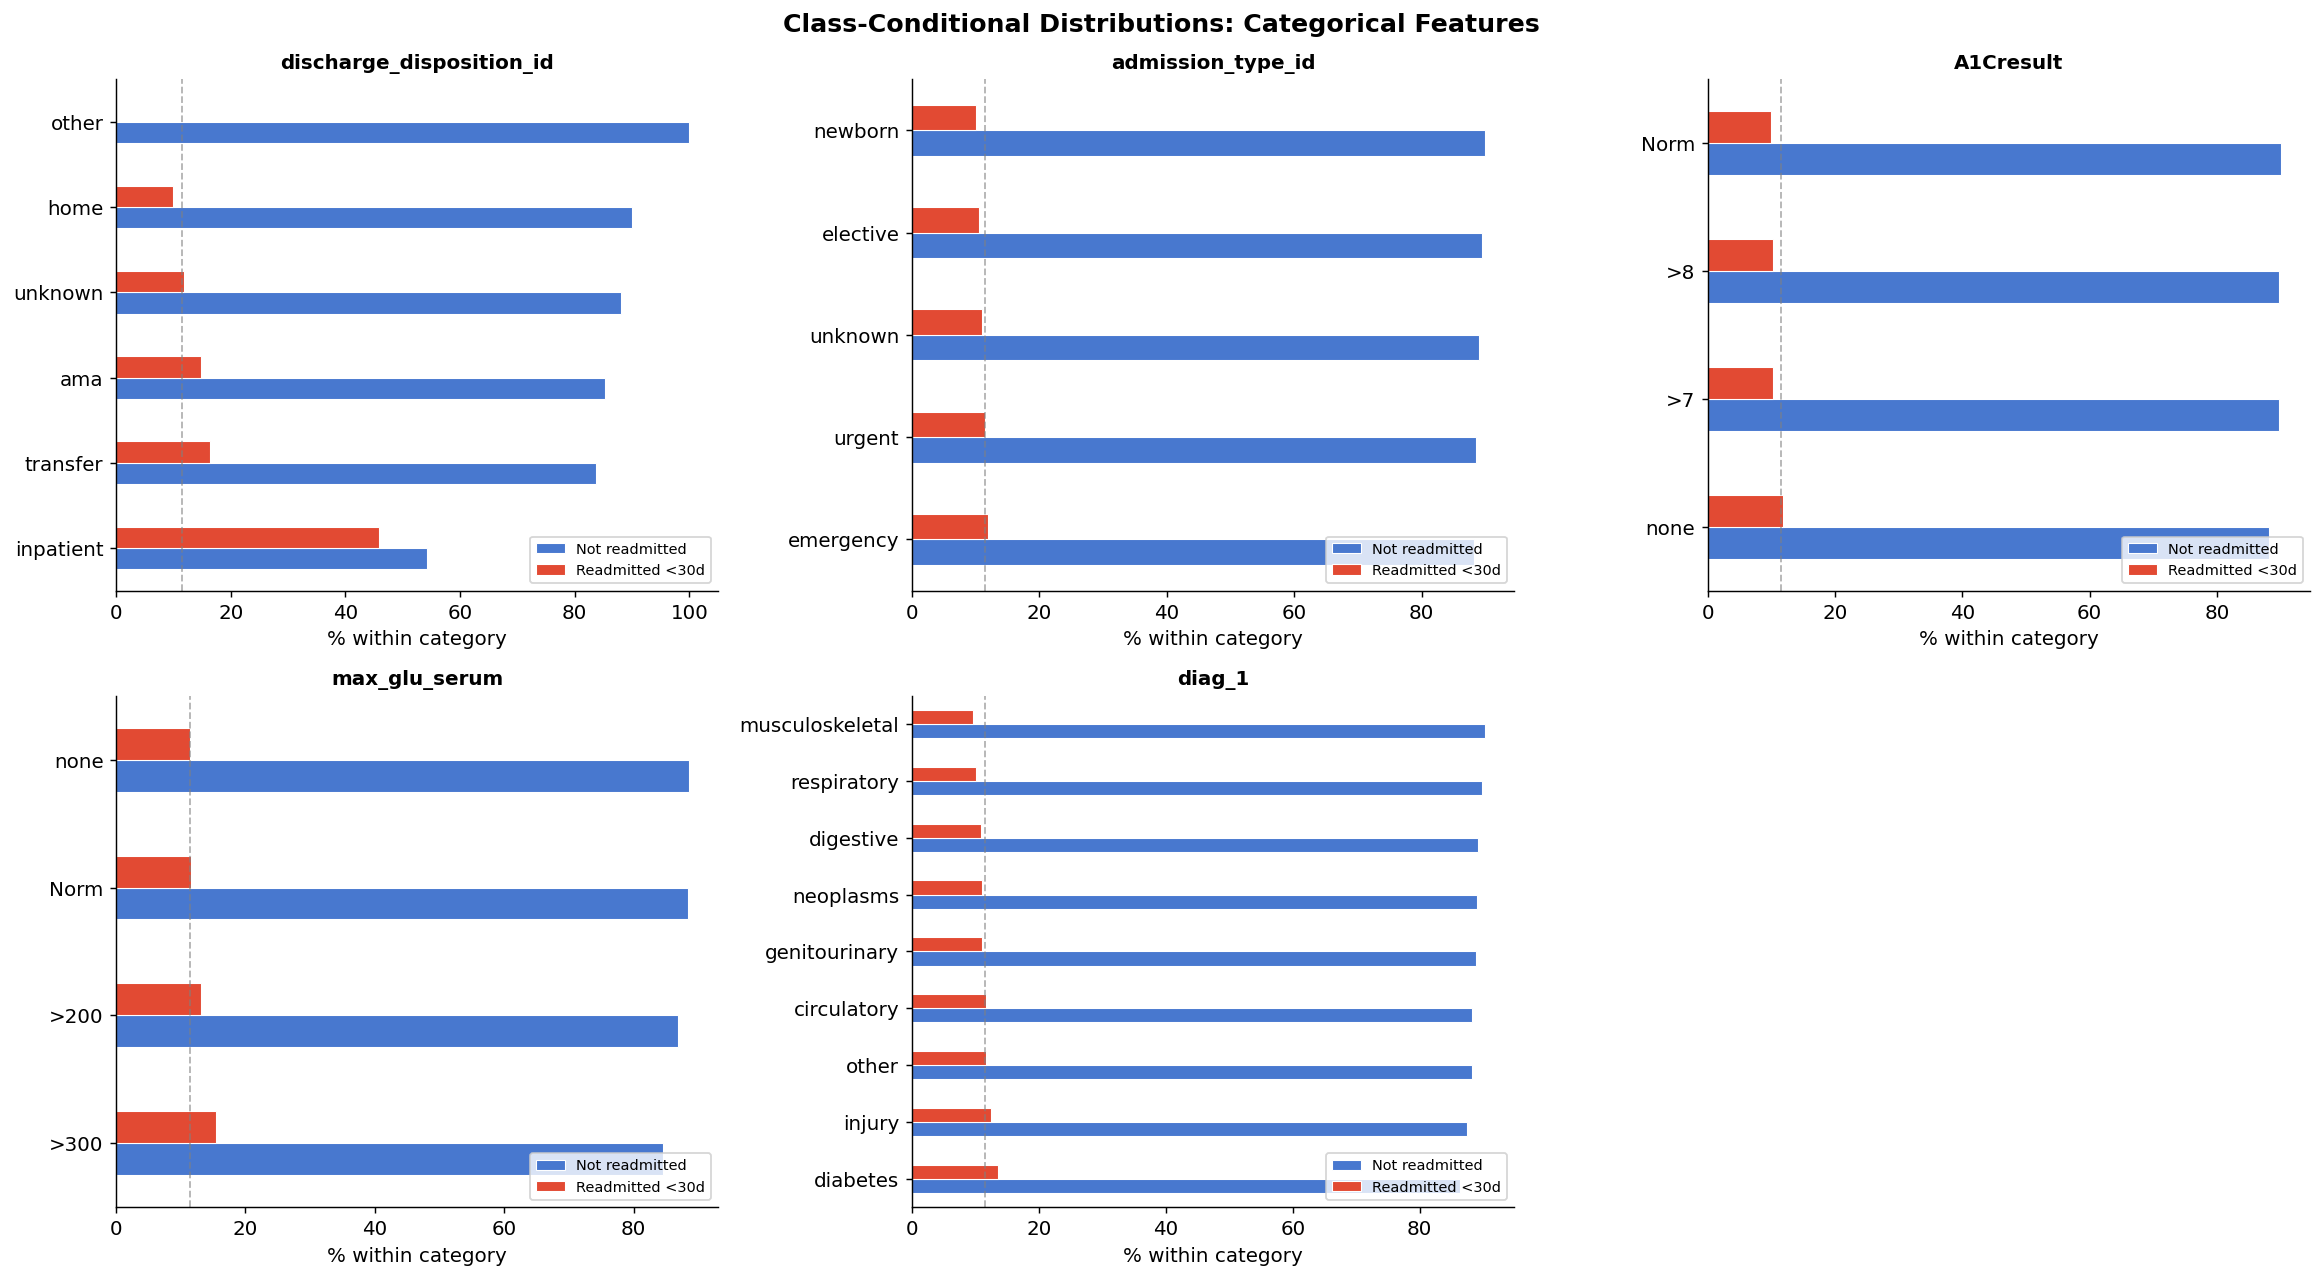

In [22]:
CAT_FEATURES = [
    'discharge_disposition_id', 'admission_type_id',
    'A1Cresult', 'max_glu_serum', 'diag_1'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Class-Conditional Distributions: Categorical Features', fontweight='bold', fontsize=14)
axes = axes.flatten()

for i, feat in enumerate(CAT_FEATURES):
    ax = axes[i]
    ct = pd.crosstab(df[feat], df['readmitted_binary'], normalize='index') * 100
    ct.columns = ['Not readmitted', 'Readmitted <30d']
    ct.sort_values('Readmitted <30d', ascending=False, inplace=True)

    ct.plot(kind='barh', ax=ax, color=list(PALETTE.values()),
            edgecolor='white', linewidth=0.6)
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.set_xlabel('% within category')
    ax.set_ylabel('')
    ax.legend(fontsize=8, loc='lower right')
    ax.axvline(x=y.mean() * 100, color='gray', linestyle='--', alpha=0.6, linewidth=1)

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('figures/03_class_conditional_categorical.png', bbox_inches='tight')
plt.show()

## 5. Engineered Features: Clinical Validation

These three features — `service_utilization`, `medication_count`, and
`HbA1c_diabetes_interaction` — were added based on the literature.
This section validates that they actually carry the expected signal.

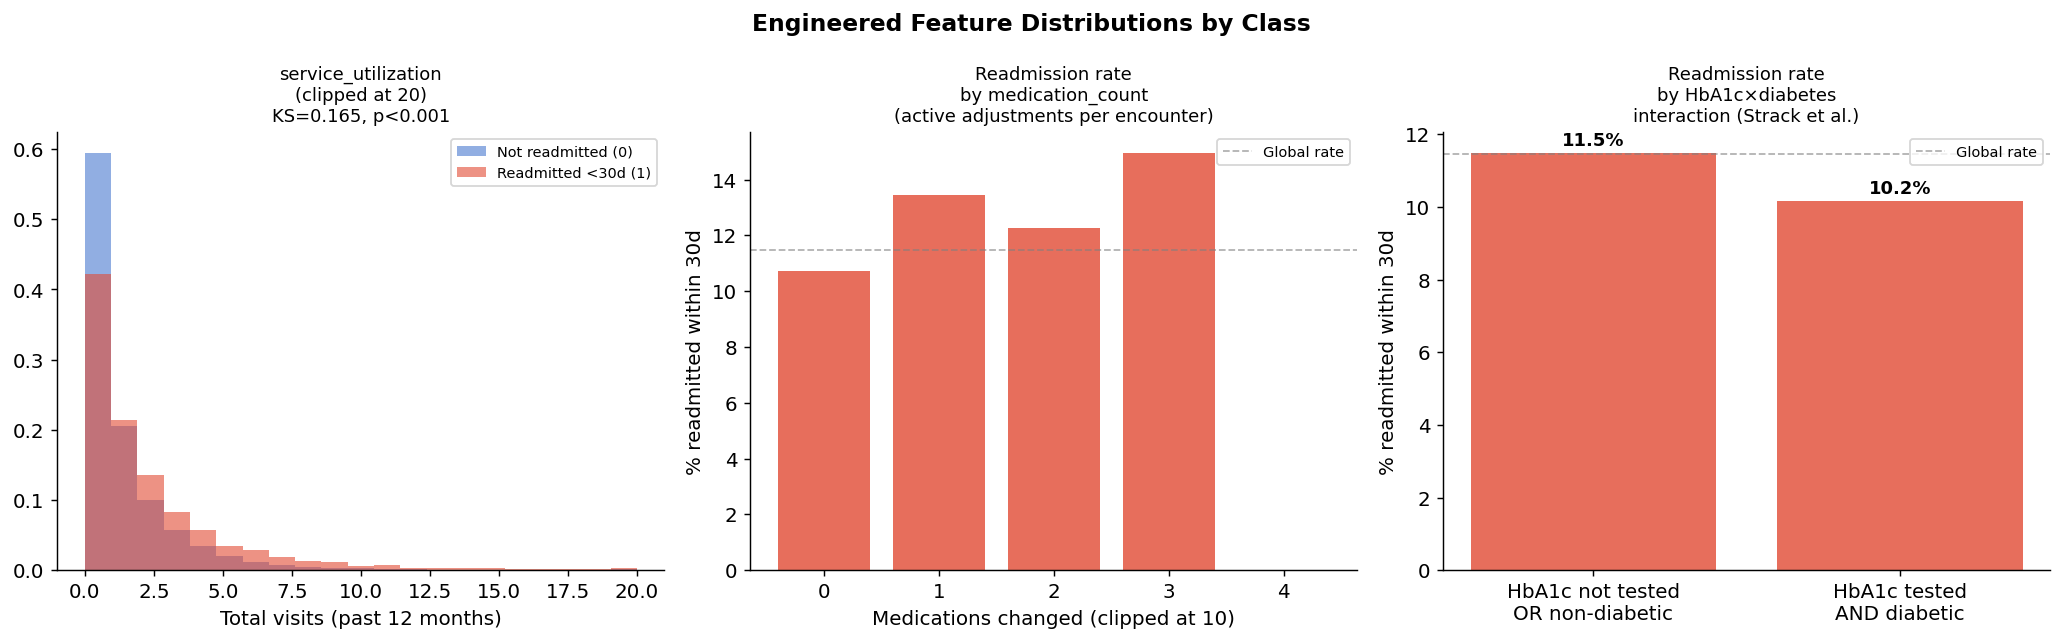

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Engineered Feature Distributions by Class', fontweight='bold', fontsize=13)

# ── service_utilization ───────────────────────────────────────────────────────
ax = axes[0]
for label, color in zip([0, 1], list(PALETTE.values())):
    vals = df[df['readmitted_binary'] == label]['service_utilization']
    ax.hist(vals.clip(upper=20), bins=21, alpha=0.6, color=color,
            density=True, label=list(PALETTE.keys())[label])
ks_s, ks_p = ks_2samp(
    df[df['readmitted_binary']==0]['service_utilization'],
    df[df['readmitted_binary']==1]['service_utilization']
)
ax.set_title(f'service_utilization\n(clipped at 20)\nKS={ks_s:.3f}, p<0.001', fontsize=10)
ax.set_xlabel('Total visits (past 12 months)')
ax.legend(fontsize=8)

# ── medication_count ──────────────────────────────────────────────────────────
ax = axes[1]
mc_cross = pd.crosstab(
    df['medication_count'].clip(upper=10),
    df['readmitted_binary'],
    normalize='index'
) * 100
if 1 in mc_cross.columns:
    ax.bar(mc_cross.index, mc_cross[1], color=list(PALETTE.values())[1], alpha=0.8)
ax.axhline(y.mean()*100, color='gray', linestyle='--', alpha=0.6, linewidth=1, label='Global rate')
ax.set_title('Readmission rate\nby medication_count\n(active adjustments per encounter)', fontsize=10)
ax.set_xlabel('Medications changed (clipped at 10)')
ax.set_ylabel('% readmitted within 30d')
ax.legend(fontsize=8)

# ── HbA1c_diabetes_interaction ────────────────────────────────────────────────
ax = axes[2]
hba1c_cross = pd.crosstab(
    df['HbA1c_diabetes_interaction'],
    df['readmitted_binary'],
    normalize='index'
) * 100
bar_labels = ['HbA1c not tested\nOR non-diabetic', 'HbA1c tested\nAND diabetic']
bars = ax.bar(
    bar_labels,
    hba1c_cross[1].values if 1 in hba1c_cross.columns else [0, 0],
    color=list(PALETTE.values())[1], alpha=0.8
)
ax.axhline(y.mean()*100, color='gray', linestyle='--', alpha=0.6, linewidth=1, label='Global rate')
for bar, val in zip(bars, hba1c_cross[1].values if 1 in hba1c_cross.columns else []):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Readmission rate\nby HbA1c×diabetes\ninteraction (Strack et al.)', fontsize=10)
ax.set_ylabel('% readmitted within 30d')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('figures/04_engineered_features.png', bbox_inches='tight')
plt.show()

## 6. Feature Correlation and Redundancy

Before studying heterogeneity, it is useful to know which continuous features move together.
Highly correlated features imply that client distribution shift in one will manifest in
correlated shifts in others — the effective dimensionality of the heterogeneity is lower
than the raw feature count.

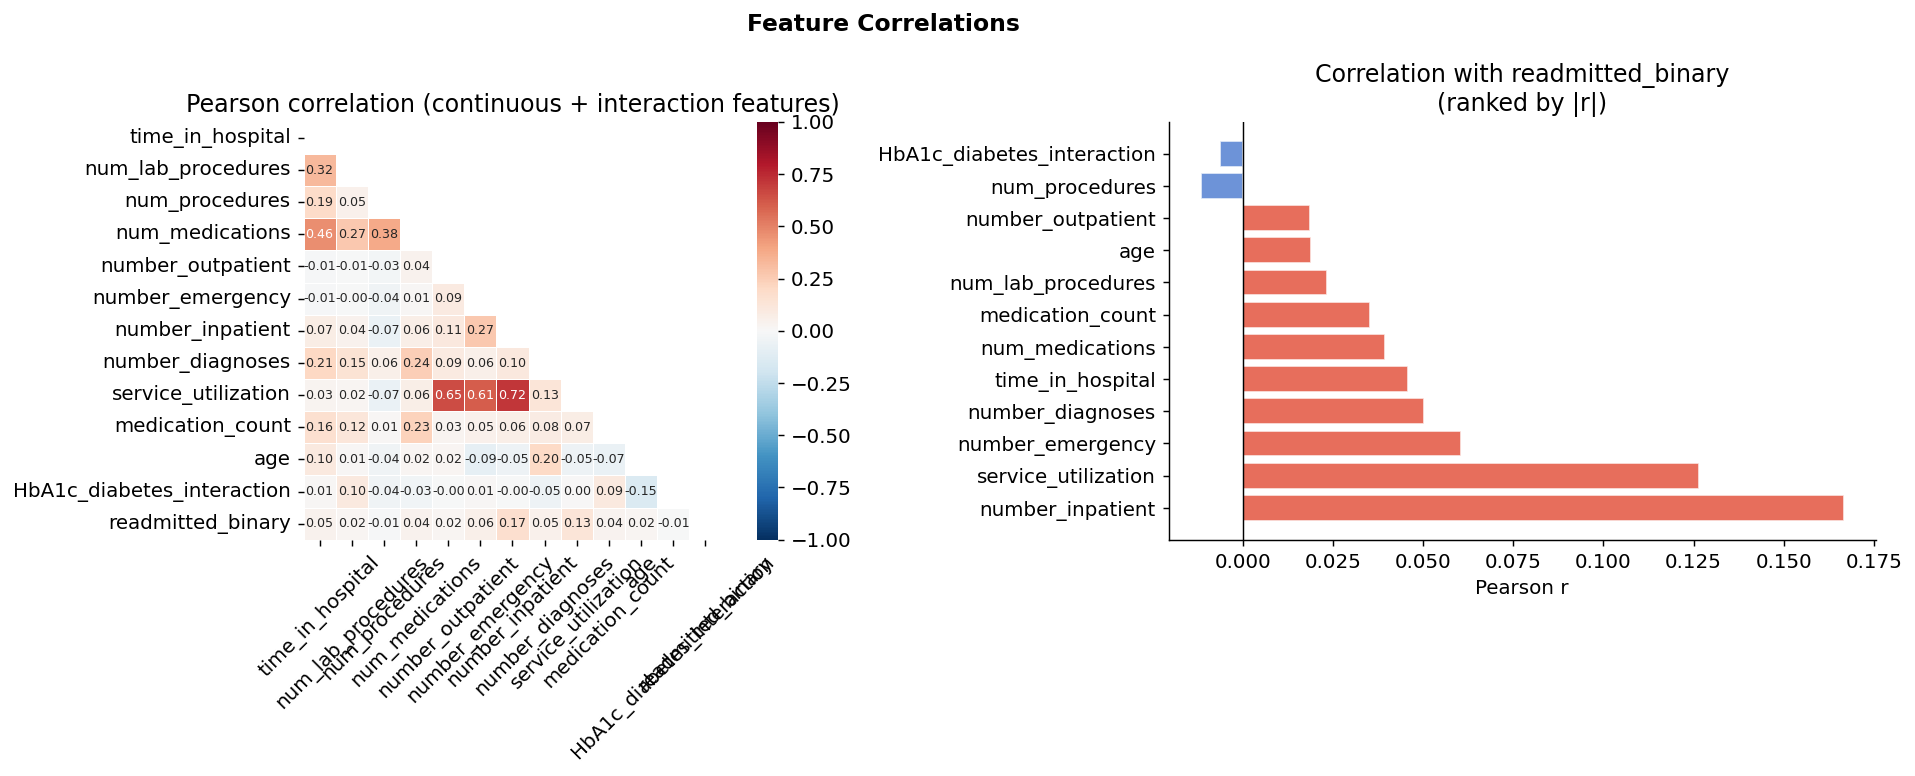

In [24]:
cont_cols = CONTINUOUS_FEATURES + ['HbA1c_diabetes_interaction']
corr = df[cont_cols + ['readmitted_binary']].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Correlations', fontweight='bold', fontsize=13)

# Full correlation matrix
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, ax=axes[0], mask=mask,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    linewidths=0.5, square=True
)
axes[0].set_title('Pearson correlation (continuous + interaction features)')
axes[0].tick_params(axis='x', rotation=45)

# Point-biserial correlation with target (discriminative power ranking)
target_corr = corr['readmitted_binary'].drop('readmitted_binary').sort_values(key=abs, ascending=False)
colors_bar = [list(PALETTE.values())[1] if v > 0 else list(PALETTE.values())[0]
              for v in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=colors_bar, alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlation with readmitted_binary\n(ranked by |r|)')
axes[1].set_xlabel('Pearson r')

plt.tight_layout()
plt.savefig('figures/05_feature_correlations.png', bbox_inches='tight')
plt.show()